C:\Users\HP\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
C:\Users\HP\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.9215 - loss: 0.2723 - val_accuracy: 0.9678 - val_loss: 0.1232
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9642 - loss: 0.1211 - val_accuracy: 0.9732 - val_loss: 0.0934
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9751 - loss: 0.0836 - val_accuracy: 0.9733 - val_loss: 0.0885
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9809 - loss: 0.0630 - val_accuracy: 0.9790 - val_loss: 0.0776
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9854 - loss: 0.0487 - val_accuracy: 0.9773 - val_loss: 0.0765
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9890 - loss: 0.0366 - val_accuracy: 0.9780 - val_loss: 0.0824
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9908 - loss: 0.0302 - val_accuracy: 0.9760 - val_loss: 0.0945
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9923 - loss: 0

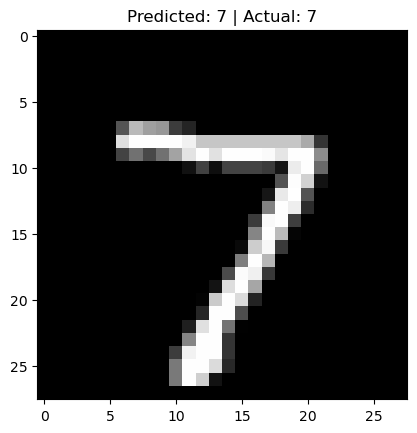

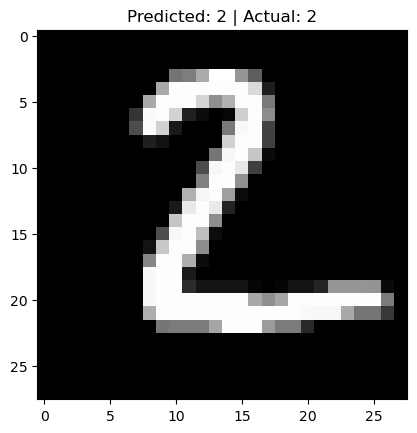

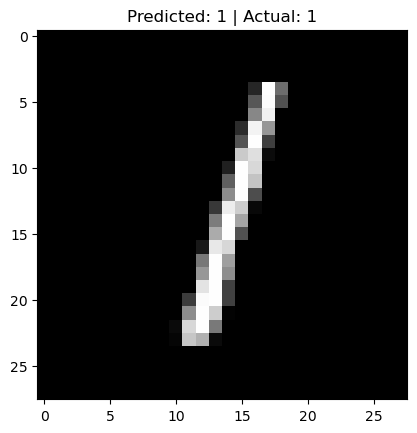

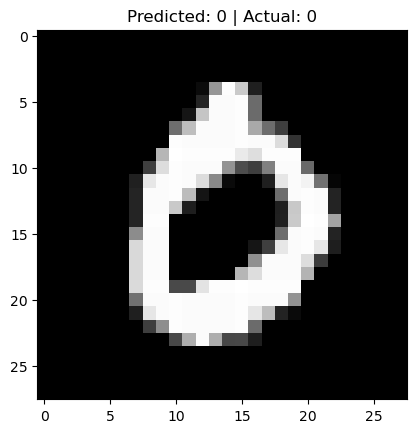

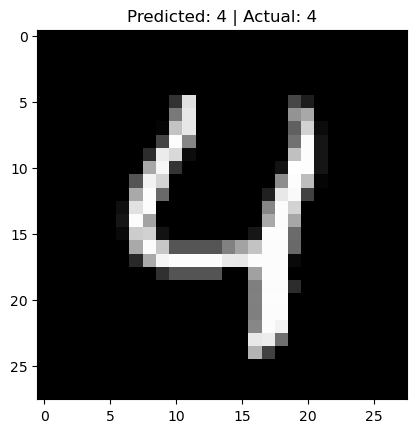

In [1]:
# ============================
# MNIST Digit Classification ANN
# ============================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# ----------------------------
# Step 1: Load MNIST dataset
# ----------------------------
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# ----------------------------
# Step 2: Preprocess data
# ----------------------------
x_train = x_train / 255.0      # Normalize pixels
x_test = x_test / 255.0

y_train = to_categorical(y_train, 10)   # One-hot encode labels
y_test = to_categorical(y_test, 10)

# ----------------------------
# Step 3: Build the ANN model
# ----------------------------
model = Sequential()
model.add(Flatten(input_shape=(28,28)))       # Flatten 28x28 images to 784 features
model.add(Dense(128, activation='relu'))      # Hidden layer with 128 neurons
model.add(Dense(10, activation='softmax'))    # Output layer with 10 neurons (digits 0-9)

# ----------------------------
# Step 4: Compile the model
# ----------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ----------------------------
# Step 5: Train the model
# ----------------------------
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

# ----------------------------
# Step 6: Evaluate the model
# ----------------------------
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

# ----------------------------
# Step 7: Predict on test images
# ----------------------------
predictions = model.predict(x_test[:5])
predicted_classes = np.argmax(predictions, axis=1)
actual_classes = np.argmax(y_test[:5], axis=1)

print("Predicted digits:", predicted_classes)
print("Actual digits:   ", actual_classes)

# ----------------------------
# Optional: Visualize first 5 test images
# ----------------------------
for i in range(5):
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Predicted: {predicted_classes[i]} | Actual: {actual_classes[i]}")
    plt.show()
